### **Week 1: Data Preprocessing & Baseline Modeling**
In this section, we prepare the cleaned Telecom data for machine learning. This involves dropping non-predictive columns, one-hot encoding categorical variables, and splitting the dataset into an 80/20 train-test split. We apply standard scaling to ensure uniform feature weight and train a baseline Logistic Regression model to establish our initial predictive accuracy.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 1. Load the cleaned data from Month 2
df = pd.read_csv('Cleaned_Churn_Data.csv')

# 2. Data Preprocessing
# Drop the customerID column because a random string of letters has no predictive value
if 'customerID' in df.columns:
    df = df.drop('customerID', axis=1)

# Convert any remaining text columns (like gender, PaymentMethod) into binary 1s and 0s
df = pd.get_dummies(df, drop_first=True)

# Separate the Features (X) from the Target Label (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split the data: 80% for training the AI, 20% for testing it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the data (This forces all numbers onto the same scale so TotalCharges doesn't overshadow tenure)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Data successfully preprocessed, split, and scaled!")

# 3. Baseline Modeling
# Initialize the Logistic Regression model
log_model = LogisticRegression(max_iter=1000)

# Train the model using the 80% training data
log_model.fit(X_train_scaled, y_train)

# 4. Quick Evaluation
# Ask the trained model to predict the churn for the 20% test data
y_pred = log_model.predict(X_test_scaled)

# Compare the model's predictions to the actual truth
accuracy = accuracy_score(y_test, y_pred)
print(f"🤖 Baseline Model Accuracy: {accuracy * 100:.2f}%")

✅ Data successfully preprocessed, split, and scaled!
🤖 Baseline Model Accuracy: 78.82%


### **Week 2: Advanced Evaluation Metrics & ROC Curve**
While baseline accuracy provides a high-level overview, it can be misleading in imbalanced datasets. In this section, we evaluate the Logistic Regression model using a Confusion Matrix, Precision, Recall, and the F1-Score. Finally, we plot the Receiver Operating Characteristic (ROC) curve to visualize the model's diagnostic ability across different probability thresholds.


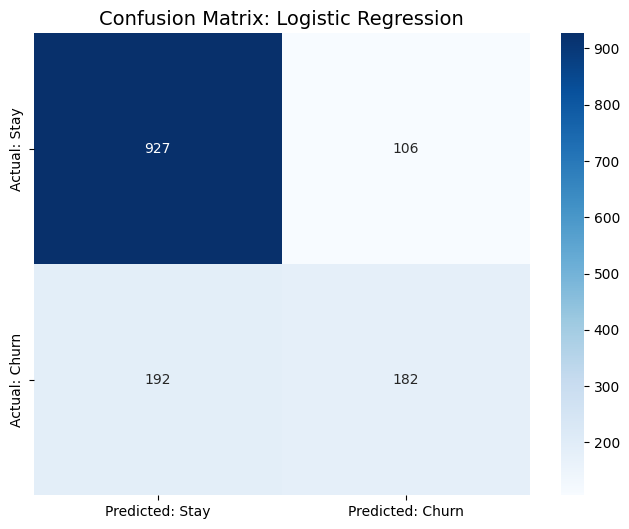


📊 Detailed Classification Report:

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.71      1407
weighted avg       0.78      0.79      0.78      1407



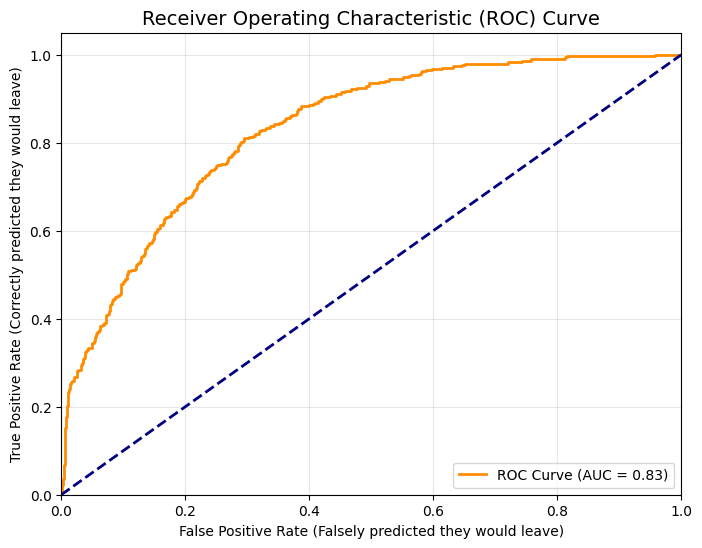

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# 1. Visualize the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Stay', 'Predicted: Churn'],
            yticklabels=['Actual: Stay', 'Actual: Churn'])
plt.title('Confusion Matrix: Logistic Regression', fontsize=14)
plt.show()

# 2. Detailed Classification Report (Precision, Recall, F1)
print("\n📊 Detailed Classification Report:\n")
print(classification_report(y_test, y_pred))

# 3. Plot the ROC-AUC Curve
# Get the raw probability scores instead of just the final 0/1 predictions
y_prob = log_model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # The 50/50 guessing line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Falsely predicted they would leave)')
plt.ylabel('True Positive Rate (Correctly predicted they would leave)')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

### **Week 3: Ensemble Modeling & Feature Importance**
To improve the recall of our minority class (Churn = 1), we upgrade from a linear model to a tree-based ensemble method: the Random Forest Classifier. By applying balanced class weights, we force the algorithm to heavily penalize misclassifications of churners. Finally, we extract the model's feature importance scores to provide business stakeholders with actionable insights into which customer attributes drive churn the most.


🌲 Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1033
           1       0.63      0.47      0.54       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



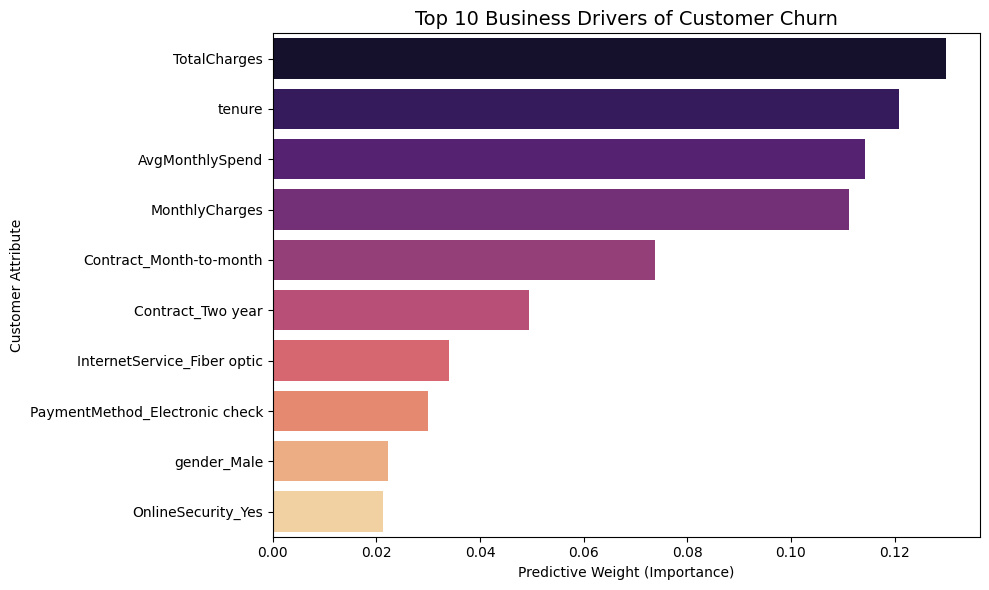

In [3]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

# 1. Initialize the Random Forest Model
# class_weight='balanced' tells the AI that catching a churner is super important
rf_model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)

# 2. Train the model
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)

# 3. Evaluate the new model
print("🌲 Random Forest Classification Report:\n")
print(classification_report(y_test, rf_pred))

# 4. Extract Feature Importance
# Match the importance scores to the actual column names
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 5. Visualize the Top 10 Drivers of Churn
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances.head(10), palette='magma', hue='Feature', legend=False)
plt.title('Top 10 Business Drivers of Customer Churn', fontsize=14)
plt.xlabel('Predictive Weight (Importance)')
plt.ylabel('Customer Attribute')
plt.tight_layout()
plt.show()

### **Week 4: Model Deployment & Live Inference**
A machine learning model provides no business value if it remains trapped in a notebook. In this final section, we build an inference function that simulates a real-world deployment. The function accepts raw customer data, applies the exact scaling transformations used during training, and outputs a clear probability score and risk classification for immediate stakeholder use.

In [4]:
import warnings
warnings.filterwarnings('ignore') # Hides annoying scaling warnings for clean output

# 1. Create the Inference Function
def predict_customer_churn(model, scaler, customer_data):
    """
    Takes a trained model, a fitted scaler, and a single customer's data row.
    Returns a business-friendly prediction.
    """
    # Scale the input using the exact same math as the training data
    scaled_data = scaler.transform([customer_data])

    # Get the probability of Class 1 (Churn)
    churn_probability = model.predict_proba(scaled_data)[0][1]

    # Business Logic Threshold
    if churn_probability >= 0.50:
        status = "🚨 HIGH CHURN RISK"
    else:
        status = "✅ SAFE"

    print(f"Customer Status: {status}")
    print(f"Probability of Leaving: {churn_probability * 100:.1f}%\n")

# 2. Simulate a Live Business Environment
print("--- LIVE RETENTION SYSTEM ---")

# Let's test it on three random customers from our test set
print("Testing Customer A (Index 5):")
predict_customer_churn(rf_model, scaler, X_test.iloc[5])

print("Testing Customer B (Index 12):")
predict_customer_churn(rf_model, scaler, X_test.iloc[12])

print("Testing Customer C (Index 42):")
predict_customer_churn(rf_model, scaler, X_test.iloc[42])

--- LIVE RETENTION SYSTEM ---
Testing Customer A (Index 5):
Customer Status: 🚨 HIGH CHURN RISK
Probability of Leaving: 50.0%

Testing Customer B (Index 12):
Customer Status: ✅ SAFE
Probability of Leaving: 1.0%

Testing Customer C (Index 42):
Customer Status: ✅ SAFE
Probability of Leaving: 4.0%

